# 5.1 · Probability and Distributions in the VitalDB Cohort

This notebook takes the ideas from Chapter 5 and tests them against real data from 6,388 surgical cases. The goal is not just to compute numbers — it is to build intuition about how probability works in practice.

**Three exercises:**

1. **Probabilities, Odds, and Risk** — Are odds and probability really the same? We compute both for mortality (rare) and elevated creatinine (common) to see exactly when the "rare disease assumption" breaks down.
2. **Fitting Distributions** — Does patient height really follow a bell curve? Is propofol dose log-normal? Do RBC transfusion counts follow a Poisson distribution? We fit the theory to the data and see where it works — and where it fails.
3. **The Central Limit Theorem** — We take the messiest, most skewed variable we can find (propofol dose) and watch the magic of the CLT transform the sampling distribution into a bell curve.

All code is collapsed — click **Show code** to reveal it.

In [1]:
# ── Imports and global settings ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

# ── Colour palette ───────────────────────────────────────────────────────────
BLUE   = '#4C72B0'
RED    = '#C44E52'
GREEN  = '#55A868'
PURPLE = '#8172B2'

DATA_DIR = Path('/Volumes/iDrisAI/VitalDBGit/vital_db')
cases = pd.read_csv(DATA_DIR / 'all_cases.csv')
labs  = pd.read_csv(DATA_DIR / 'labs.csv')

print(f"cases: {len(cases):,} rows, {cases.shape[1]} columns")
print(f"labs:  {len(labs):,} rows, {labs.shape[1]} columns")

cases: 6,388 rows, 74 columns
labs:  928,448 rows, 4 columns


---
## Exercise 1 — Do Odds and Probability Really Mean the Same Thing?

Textbooks say "for rare outcomes, odds ≈ probability." Let us test that claim directly.

We will compute probability, odds, relative risk, and odds ratios for two outcomes across ASA classes:
- **In-hospital mortality** — a rare event (~0.9% overall). Here odds and probability should be nearly identical.
- **Elevated creatinine** (Cr > 1.2 mg/dL) — a more common finding. Here we expect odds ratios to overstate the true relative risk.

The question is not whether the textbook is right (it is) — it is *how much* the numbers diverge, and whether the difference matters clinically.

In [2]:
# ── Mortality: probability, odds, RR by ASA class ────────────────────────────
asa_valid = cases[cases['asa'].isin([1, 2, 3, 4])].copy()
asa_valid['died'] = (asa_valid['death_inhosp'] == 1).astype(int)

print("In-Hospital Mortality by ASA Class")
print("=" * 75)
print(f"{'ASA':>4}  {'n':>6}  {'Deaths':>7}  {'Prob':>8}  {'Odds':>10}  {'RR vs ASA I':>12}  {'OR vs ASA I':>12}")
print("-" * 75)

# Compute baseline (ASA I)
asa1 = asa_valid[asa_valid['asa'] == 1]
p_baseline = asa1['died'].mean()
odds_baseline = p_baseline / (1 - p_baseline) if p_baseline > 0 else 0

results_mortality = []
for asa_class in [1, 2, 3, 4]:
    group = asa_valid[asa_valid['asa'] == asa_class]
    n = len(group)
    deaths = group['died'].sum()
    prob = group['died'].mean()
    odds = prob / (1 - prob) if prob > 0 else 0
    rr = prob / p_baseline if p_baseline > 0 else float('inf')
    or_val = (odds / odds_baseline) if odds_baseline > 0 else float('inf')
    results_mortality.append({'asa': asa_class, 'n': n, 'deaths': deaths,
                              'prob': prob, 'odds': odds, 'rr': rr, 'or': or_val})
    rr_str = f"{rr:.1f}" if asa_class > 1 else "ref"
    or_str = f"{or_val:.1f}" if asa_class > 1 else "ref"
    print(f"{asa_class:>4}  {n:>6,}  {deaths:>7}  {prob:>8.4f}  {odds:>10.5f}  {rr_str:>12}  {or_str:>12}")

print(f"\nTotal patients: {len(asa_valid):,}")
print(f"Overall mortality: {asa_valid['died'].sum()} / {len(asa_valid):,} = {asa_valid['died'].mean():.4f}")
print("\n→ For this rare outcome, probability ≈ odds and RR ≈ OR.")

In-Hospital Mortality by ASA Class
 ASA       n   Deaths      Prob        Odds   RR vs ASA I   OR vs ASA I
---------------------------------------------------------------------------
   1   1,792        9    0.0050     0.00505           ref           ref
   2   3,699       17    0.0046     0.00462           0.9           0.9
   3     703       17    0.0242     0.02478           4.8           4.9
   4      48       12    0.2500     0.33333          49.8          66.0

Total patients: 6,242
Overall mortality: 55 / 6,242 = 0.0088

→ For this rare outcome, probability ≈ odds and RR ≈ OR.


In [3]:
# ── More common outcome: elevated creatinine (Cr > 1.2 mg/dL) ────────────────
cr_valid = cases[cases['preop_cr'].notna() & cases['asa'].isin([1, 2, 3, 4])].copy()
cr_valid['elevated_cr'] = (cr_valid['preop_cr'] > 1.2).astype(int)

print("Elevated Preoperative Creatinine (> 1.2 mg/dL) by ASA Class")
print("=" * 80)
print(f"{'ASA':>4}  {'n':>6}  {'Events':>7}  {'Prob':>8}  {'Odds':>8}  "
      f"{'RR vs I':>10}  {'OR vs I':>10}  {'OR/RR':>8}")
print("-" * 80)

asa1_cr = cr_valid[cr_valid['asa'] == 1]
p_base_cr = asa1_cr['elevated_cr'].mean()
odds_base_cr = p_base_cr / (1 - p_base_cr) if p_base_cr > 0 else 0

for asa_class in [1, 2, 3, 4]:
    group = cr_valid[cr_valid['asa'] == asa_class]
    n = len(group)
    events = group['elevated_cr'].sum()
    prob = group['elevated_cr'].mean()
    odds = prob / (1 - prob) if prob > 0 else 0
    rr = prob / p_base_cr if p_base_cr > 0 else float('inf')
    or_val = (odds / odds_base_cr) if odds_base_cr > 0 else float('inf')
    ratio = or_val / rr if rr > 0 else float('inf')
    rr_str = f"{rr:.2f}" if asa_class > 1 else "ref"
    or_str = f"{or_val:.2f}" if asa_class > 1 else "ref"
    ratio_str = f"{ratio:.2f}" if asa_class > 1 else "—"
    print(f"{asa_class:>4}  {n:>6,}  {events:>7}  {prob:>8.3f}  {odds:>8.3f}  "
          f"{rr_str:>10}  {or_str:>10}  {ratio_str:>8}")

print("\n→ For this more common outcome, OR consistently exceeds RR.")
print("  The OR/RR ratio increases as the outcome becomes more prevalent.")

Elevated Preoperative Creatinine (> 1.2 mg/dL) by ASA Class
 ASA       n   Events      Prob      Odds     RR vs I     OR vs I     OR/RR
--------------------------------------------------------------------------------
   1   1,707       21     0.012     0.012         ref         ref         —
   2   3,572      258     0.072     0.078        5.87        6.25      1.06
   3     677      208     0.307     0.443       24.97       35.61      1.43
   4      47       18     0.383     0.621       31.13       49.83      1.60

→ For this more common outcome, OR consistently exceeds RR.
  The OR/RR ratio increases as the outcome becomes more prevalent.


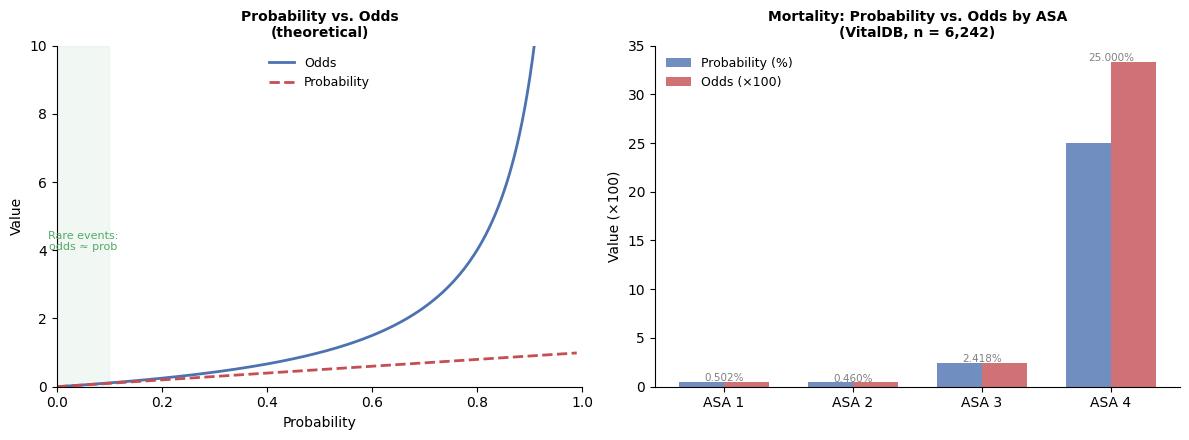

In [4]:
# ── Visualise: probability vs odds across the probability range ─────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: theoretical relationship
ax = axes[0]
p_range = np.linspace(0.001, 0.99, 200)
odds_range = p_range / (1 - p_range)
ax.plot(p_range, odds_range, color=BLUE, linewidth=2, label='Odds')
ax.plot(p_range, p_range, color=RED, linewidth=2, linestyle='--', label='Probability')
ax.axvspan(0, 0.10, alpha=0.08, color=GREEN)
ax.text(0.05, 4, 'Rare events:\nodds ≈ prob', fontsize=8, ha='center', color=GREEN)
ax.set_xlabel('Probability', fontsize=10)
ax.set_ylabel('Value', fontsize=10)
ax.set_title('Probability vs. Odds\n(theoretical)', fontsize=10, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 10)
ax.legend(fontsize=9, frameon=False)

# Right: VitalDB mortality by ASA
ax = axes[1]
asa_classes = [r['asa'] for r in results_mortality]
probs = [r['prob'] for r in results_mortality]
odds_vals = [r['odds'] for r in results_mortality]
x_pos = np.arange(len(asa_classes))
width = 0.35
ax.bar(x_pos - width/2, [p * 100 for p in probs], width, color=BLUE, alpha=0.8, label='Probability (%)')
ax.bar(x_pos + width/2, [o * 100 for o in odds_vals], width, color=RED, alpha=0.8, label='Odds (×100)')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'ASA {c}' for c in asa_classes])
ax.set_ylabel('Value (×100)', fontsize=10)
ax.set_title('Mortality: Probability vs. Odds by ASA\n(VitalDB, n = {:,})'.format(len(asa_valid)),
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9, frameon=False)

for i, (p, o) in enumerate(zip(probs, odds_vals)):
    if p > 0:
        ax.text(i, max(p, o) * 100 + 0.05, f'{p:.3%}', ha='center', fontsize=7.5, color='grey')

plt.tight_layout()
plt.show()

### What did we learn?

**Look at the mortality table first.** For ASA I through III, the "Prob" and "Odds" columns are virtually identical — because mortality is rare (< 3%), the denominator barely changes when you switch from "out of everyone" to "out of survivors." The RR and OR columns also match closely.

But then look at **ASA IV**: probability is 0.25 (1 in 4), but odds are 0.33 (1 in 3). The OR of 66 is dramatically larger than the RR of 50. For a reader who does not know the difference, reporting "OR = 66" instead of "RR = 50" makes the risk sound 30% worse than it actually is.

**Now look at the creatinine table.** The outcome is much more common (30%+ in ASA III–IV), and the OR/RR ratio climbs to 1.4–1.6. An odds ratio of 50 corresponds to a risk ratio of only 31. The gap is no longer academic — it is large enough to change clinical interpretation.

> **The bottom line for reading papers:** When you see an odds ratio from a logistic regression study, ask yourself: "Is the outcome rare?" If the answer is yes (< 10%), the OR is a reasonable approximation of the RR. If the answer is no — as with common outcomes like nausea, hypotension, or elevated biomarkers — the OR exaggerates the true relative risk, and you should interpret it cautiously.

---
## Exercise 2 — Does the Theory Fit the Data?

Statistics textbooks are full of theoretical distributions — the Normal, the Log-normal, the Poisson. But do real clinical variables actually follow these shapes?

Here we take four VitalDB variables and try to fit the "right" theoretical distribution to each. For each variable, we show:
- A **histogram** with the fitted curve overlaid — so you can see visually how well the theory matches reality
- A **Q-Q plot** — a more rigorous visual check (if the data follows the distribution, the points will fall on a straight line)
- A **Kolmogorov–Smirnov (KS) test** — a formal statistical test of goodness-of-fit

| Variable | What we expect | Why |
|---|---|---|
| Patient height | Normal (bell curve) | Height results from adding many small genetic and environmental effects |
| Propofol total dose | Log-normal (right-skewed) | Drug requirements involve multiplicative factors (weight, metabolism, tolerance) |
| Preoperative creatinine | Log-normal (right-skewed) | Most patients have normal values; a minority have very high values from kidney disease |
| RBC transfusion units | Poisson (counts of rare events) | Most patients get 0 units; a few get several |

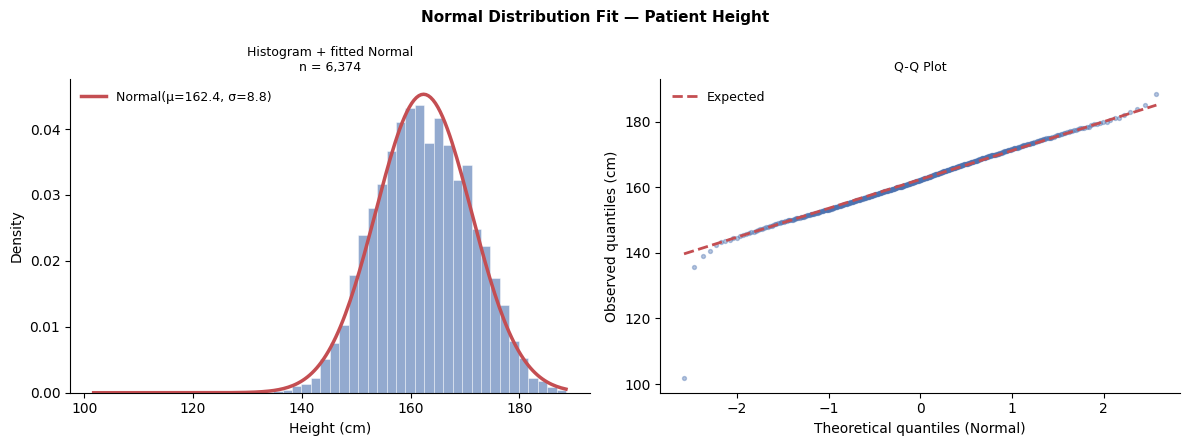

Normal fit: μ = 162.4 cm, σ = 8.8 cm
KS statistic = 0.0186, p = 0.0237
Note: KS test rejects normality (p < 0.05) because n = 6,374 is very large.
The Q-Q plot shows the fit is excellent for practical purposes.


In [5]:
# ── Normal fit: patient height ───────────────────────────────────────────────
height = cases['height'].dropna()
height = height[(height > 100) & (height < 210)]  # exclude implausible

mu, sigma = stats.norm.fit(height)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Normal Distribution Fit — Patient Height', fontsize=11, fontweight='bold')

# Histogram + fitted PDF
ax = axes[0]
ax.hist(height, bins=50, density=True, alpha=0.6, color=BLUE, edgecolor='white', linewidth=0.5)
x_range = np.linspace(height.min(), height.max(), 200)
ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), color=RED, linewidth=2.5, label=f'Normal(μ={mu:.1f}, σ={sigma:.1f})')
ax.set_xlabel('Height (cm)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title(f'Histogram + fitted Normal\nn = {len(height):,}', fontsize=9)
ax.legend(fontsize=9, frameon=False)

# Q-Q plot
ax = axes[1]
theoretical_q = stats.norm.ppf(np.linspace(0.005, 0.995, len(height)))
empirical_q = np.sort(height.values)
# Subsample for legibility
idx = np.linspace(0, len(empirical_q) - 1, 500).astype(int)
ax.scatter(theoretical_q[idx], empirical_q[idx], alpha=0.4, s=8, color=BLUE)
# Reference line
ax.plot([theoretical_q[0], theoretical_q[-1]],
        [mu + sigma * theoretical_q[0], mu + sigma * theoretical_q[-1]],
        color=RED, linewidth=2, linestyle='--', label='Expected')
ax.set_xlabel('Theoretical quantiles (Normal)', fontsize=10)
ax.set_ylabel('Observed quantiles (cm)', fontsize=10)
ax.set_title('Q-Q Plot', fontsize=9)
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

# KS test
ks_stat, ks_p = stats.kstest(height, 'norm', args=(mu, sigma))
print(f"Normal fit: μ = {mu:.1f} cm, σ = {sigma:.1f} cm")
print(f"KS statistic = {ks_stat:.4f}, p = {ks_p:.4f}")
print(f"Note: KS test rejects normality (p < 0.05) because n = {len(height):,} is very large.")
print(f"The Q-Q plot shows the fit is excellent for practical purposes.")

Propofol Total Dose: geometric mean = 105.6 mg, log-SD = 0.27, KS p = 0.0000
Preoperative Creatinine: geometric mean = 0.8 mg/dL, log-SD = 0.49, KS p = 0.0000


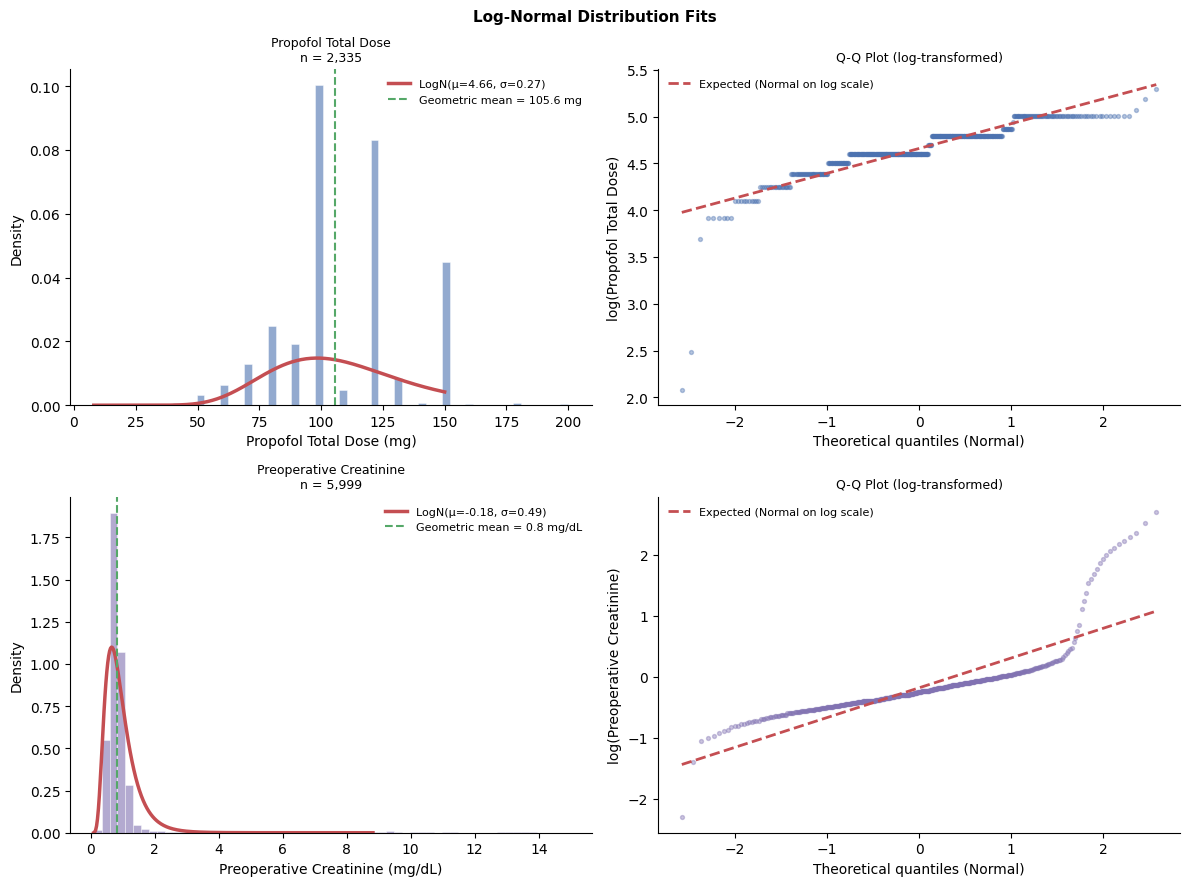

In [6]:
# ── Log-normal fit: propofol total dose and preoperative creatinine ──────────
ppf = cases['intraop_ppf'].dropna()
ppf = ppf[ppf > 0]  # Exclude zero-dose (volatile-only) cases

cr = cases['preop_cr'].dropna()
cr = cr[(cr > 0) & (cr < 15)]  # Exclude implausible values

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Log-Normal Distribution Fits', fontsize=11, fontweight='bold')

for row, (data, name, unit, colour) in enumerate([
    (ppf, 'Propofol Total Dose', 'mg', BLUE),
    (cr, 'Preoperative Creatinine', 'mg/dL', PURPLE),
]):
    log_data = np.log(data)
    log_mu = log_data.mean()
    log_sigma = log_data.std()
    geom_mean = np.exp(log_mu)

    # Histogram + fitted PDF
    ax = axes[row, 0]
    ax.hist(data, bins=60, density=True, alpha=0.6, color=colour, edgecolor='white', linewidth=0.5)
    x_range = np.linspace(data.min(), data.quantile(0.99), 300)
    pdf_vals = stats.lognorm.pdf(x_range, s=log_sigma, scale=geom_mean)
    ax.plot(x_range, pdf_vals, color=RED, linewidth=2.5,
            label=f'LogN(μ={log_mu:.2f}, σ={log_sigma:.2f})')
    ax.axvline(geom_mean, color=GREEN, linewidth=1.5, linestyle='--',
               label=f'Geometric mean = {geom_mean:.1f} {unit}')
    ax.set_xlabel(f'{name} ({unit})', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{name}\nn = {len(data):,}', fontsize=9)
    ax.legend(fontsize=8, frameon=False)

    # Q-Q plot on log scale
    ax = axes[row, 1]
    theoretical_q = stats.norm.ppf(np.linspace(0.005, 0.995, len(data)))
    empirical_q = np.sort(log_data.values)
    idx = np.linspace(0, len(empirical_q) - 1, 500).astype(int)
    ax.scatter(theoretical_q[idx], empirical_q[idx], alpha=0.4, s=8, color=colour)
    ax.plot([theoretical_q[0], theoretical_q[-1]],
            [log_mu + log_sigma * theoretical_q[0], log_mu + log_sigma * theoretical_q[-1]],
            color=RED, linewidth=2, linestyle='--', label='Expected (Normal on log scale)')
    ax.set_xlabel('Theoretical quantiles (Normal)', fontsize=10)
    ax.set_ylabel(f'log({name})', fontsize=10)
    ax.set_title(f'Q-Q Plot (log-transformed)', fontsize=9)
    ax.legend(fontsize=8, frameon=False)

    # KS test on log-transformed data
    ks_stat, ks_p = stats.kstest(log_data, 'norm', args=(log_mu, log_sigma))
    print(f"{name}: geometric mean = {geom_mean:.1f} {unit}, "
          f"log-SD = {log_sigma:.2f}, KS p = {ks_p:.4f}")

plt.tight_layout()
plt.show()

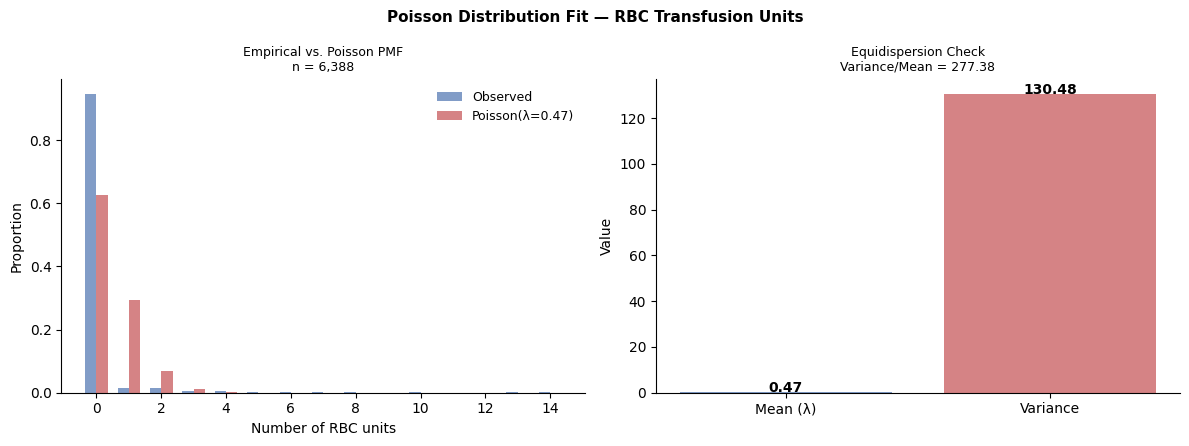

RBC transfusion: mean = 0.47 units, variance = 130.48
Variance/Mean ratio = 277.38
→ Substantial overdispersion detected. The Poisson model underestimates
  the frequency of zero transfusions and high transfusion counts.
  A zero-inflated Poisson or negative binomial model would be more appropriate.


In [7]:
# ── Poisson fit: RBC transfusion units ───────────────────────────────────────
rbc = cases['intraop_rbc'].dropna()
rbc_int = rbc.round().astype(int)
rbc_int = rbc_int[rbc_int >= 0]

lam = rbc_int.mean()
var_rbc = rbc_int.var()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Poisson Distribution Fit — RBC Transfusion Units', fontsize=11, fontweight='bold')

# Empirical vs Poisson PMF
ax = axes[0]
max_k = min(int(rbc_int.quantile(0.995)) + 1, 20)
k_range = np.arange(0, max_k + 1)
empirical_freq = rbc_int.value_counts(normalize=True).reindex(k_range, fill_value=0)
poisson_pmf = stats.poisson.pmf(k_range, lam)

width = 0.35
ax.bar(k_range - width/2, empirical_freq.values, width, color=BLUE, alpha=0.7, label='Observed')
ax.bar(k_range + width/2, poisson_pmf, width, color=RED, alpha=0.7, label=f'Poisson(λ={lam:.2f})')
ax.set_xlabel('Number of RBC units', fontsize=10)
ax.set_ylabel('Proportion', fontsize=10)
ax.set_title(f'Empirical vs. Poisson PMF\nn = {len(rbc_int):,}', fontsize=9)
ax.legend(fontsize=9, frameon=False)
ax.set_xticks(k_range[::2])

# Dispersion diagnostic
ax = axes[1]
# Show mean vs variance
ax.bar([0, 1], [lam, var_rbc], color=[BLUE, RED], alpha=0.7)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Mean (λ)', 'Variance'])
ax.set_ylabel('Value', fontsize=10)
ax.set_title(f'Equidispersion Check\nVariance/Mean = {var_rbc/lam:.2f}', fontsize=9)
for i, v in enumerate([lam, var_rbc]):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"RBC transfusion: mean = {lam:.2f} units, variance = {var_rbc:.2f}")
print(f"Variance/Mean ratio = {var_rbc/lam:.2f}")
if var_rbc / lam > 1.5:
    print("→ Substantial overdispersion detected. The Poisson model underestimates")
    print("  the frequency of zero transfusions and high transfusion counts.")
    print("  A zero-inflated Poisson or negative binomial model would be more appropriate.")
else:
    print("→ Variance/mean ratio close to 1: Poisson assumption is reasonable.")

### What did we learn?

**Height is genuinely bell-shaped.** The Q-Q plot follows the reference line almost perfectly. The KS test technically rejects normality — but do not be alarmed. With 6,000+ data points, the KS test has enough power to detect *any* deviation from perfection, no matter how tiny. The practical question is "is the normal distribution a useful approximation for height?" and the answer, clearly, is yes.

**Propofol dose and creatinine are classic log-normal variables.** Look at the histograms: both have a hump on the left and a long tail stretching right. This is exactly what you see with any variable where most patients have a typical value but some have much higher values. When we take the logarithm, the skew disappears and the Q-Q plot becomes linear. The **geometric mean** (shown as the green dashed line) is the right measure of "typical" for these variables — the ordinary arithmetic mean is pulled too high by the tail.

**RBC transfusion is where the theory breaks down.** The Poisson distribution assumes that mean = variance, but our transfusion data has a variance far exceeding the mean (overdispersion). Why? Because there are really two types of patients mixed together: those who never needed a transfusion (the vast majority) and those who did (and some of those needed many units). This mixture of "zero" and "non-zero" processes creates more zeros and more extreme values than a single Poisson distribution can explain. A **zero-inflated model** or **negative binomial** would be needed here.

> **The take-home message:** Checking distributional assumptions takes seconds — a histogram and a Q-Q plot. Skipping this step and blindly applying methods that assume normality (or Poisson, or any other distribution) to data that does not follow that shape can produce misleading results. Always look at your data first.

---
## Exercise 3 — Watching the Central Limit Theorem Happen

This is the most important demonstration in the chapter.

The propofol dose distribution is a mess — heavily right-skewed, with a long tail of very high doses. It looks nothing like a bell curve. And yet, the Central Limit Theorem promises that if we compute the *average* dose from random samples, those averages will form a bell curve — even though the individual values do not.

Let us test this promise directly. We will:
1. Draw 2,000 random samples at each of four sample sizes (n = 5, 30, 100, 500)
2. Compute the mean of each sample
3. Plot the distribution of those means
4. Check whether the distribution is normal using the Shapiro–Wilk test

**What to look for:** In the top row, you will see the original skewed population. In the bottom row, watch the sampling distribution transform from skewed (small n) to symmetric and bell-shaped (large n). That transformation *is* the CLT.

    n    Mean of means    SE (theoretical)    SE (observed)    Shapiro-Wilk p
---------------------------------------------------------------------------
    5            109.4                11.2             10.9            0.0898
   30            108.7                 4.6              4.5            0.8081
  100            108.9                 2.5              2.5            0.6116
  500            108.8                 1.1              1.1            0.3653


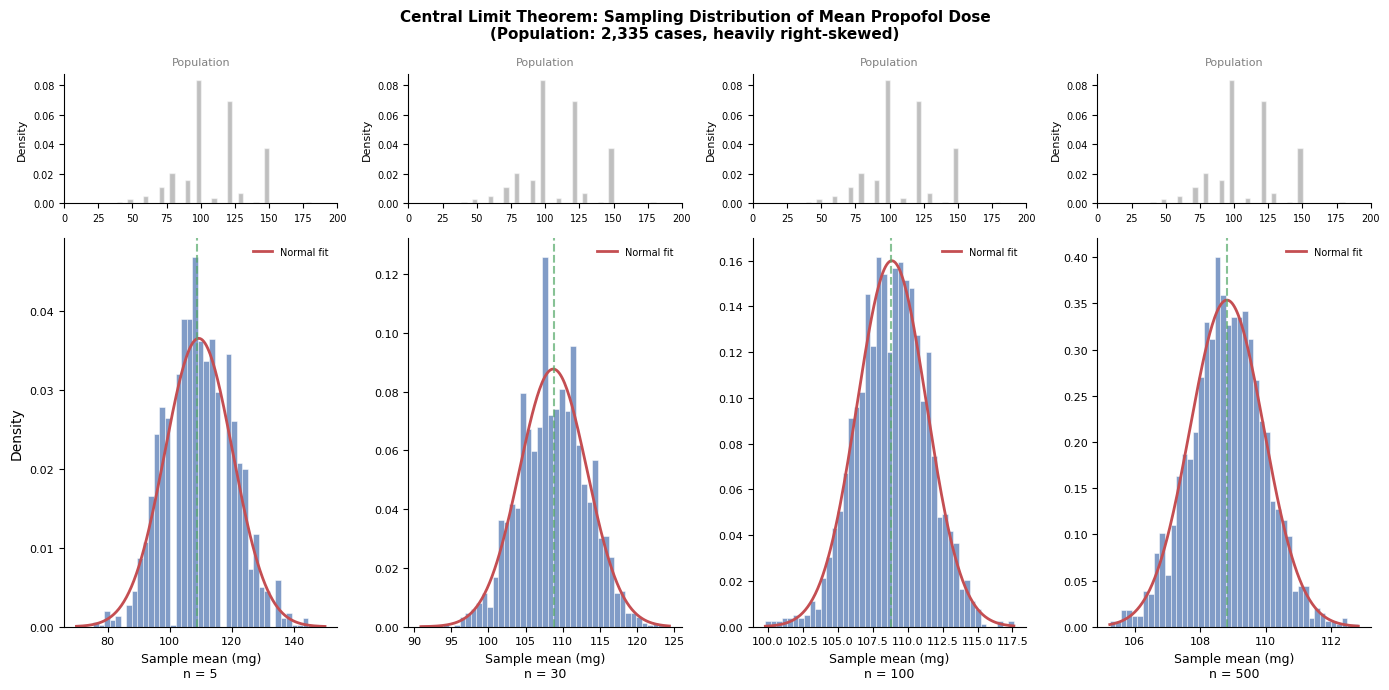


Population mean = 108.8 mg, SD = 24.9 mg
The sampling distribution narrows as √n and becomes more symmetric.
By n = 100, the Shapiro-Wilk test no longer rejects normality of the sample means.


In [8]:
# ── CLT demonstration: sampling distribution of mean propofol dose ──────────
np.random.seed(42)

ppf_vals = cases['intraop_ppf'].dropna().values
ppf_vals = ppf_vals[ppf_vals > 0]  # Exclude zero-dose cases

sample_sizes = [5, 30, 100, 500]
n_reps = 2000

fig, axes = plt.subplots(2, len(sample_sizes), figsize=(14, 7),
                         gridspec_kw={'height_ratios': [1, 3]})
fig.suptitle('Central Limit Theorem: Sampling Distribution of Mean Propofol Dose\n'
             f'(Population: {len(ppf_vals):,} cases, heavily right-skewed)',
             fontsize=11, fontweight='bold')

# Top row: show the original distribution (same in all panels for reference)
for ax in axes[0]:
    ax.hist(ppf_vals, bins=50, density=True, alpha=0.5, color='grey', edgecolor='white')
    ax.set_xlim(0, ppf_vals.max())
    ax.set_ylabel('Density', fontsize=8)
    ax.set_title('Population', fontsize=8, color='grey')
    ax.tick_params(labelsize=7)

# Bottom row: sampling distributions
print(f"{'n':>5}  {'Mean of means':>15}  {'SE (theoretical)':>18}  {'SE (observed)':>15}  {'Shapiro-Wilk p':>16}")
print("-" * 75)

pop_mean = ppf_vals.mean()
pop_sd   = ppf_vals.std()

for i, n in enumerate(sample_sizes):
    means = np.array([np.random.choice(ppf_vals, size=n, replace=True).mean()
                      for _ in range(n_reps)])

    ax = axes[1, i]
    ax.hist(means, bins=45, density=True, alpha=0.7, color=BLUE, edgecolor='white', linewidth=0.5)

    # Overlay fitted normal
    x_fit = np.linspace(means.min(), means.max(), 200)
    ax.plot(x_fit, stats.norm.pdf(x_fit, means.mean(), means.std()),
            color=RED, linewidth=2, label='Normal fit')
    ax.axvline(pop_mean, color=GREEN, linewidth=1.5, linestyle='--', alpha=0.7)
    ax.set_xlabel(f'Sample mean (mg)\nn = {n}', fontsize=9)
    if i == 0:
        ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=7, frameon=False)
    ax.tick_params(labelsize=8)

    # Shapiro-Wilk on the sample means
    sw_stat, sw_p = stats.shapiro(means[:500])  # Shapiro-Wilk limited to 5000
    se_theoretical = pop_sd / np.sqrt(n)
    se_observed = means.std()

    print(f"{n:>5}  {means.mean():>15.1f}  {se_theoretical:>18.1f}  {se_observed:>15.1f}  {sw_p:>16.4f}")

plt.tight_layout()
plt.show()

print(f"\nPopulation mean = {pop_mean:.1f} mg, SD = {pop_sd:.1f} mg")
print(f"The sampling distribution narrows as √n and becomes more symmetric.")
print(f"By n = 100, the Shapiro-Wilk test no longer rejects normality of the sample means.")

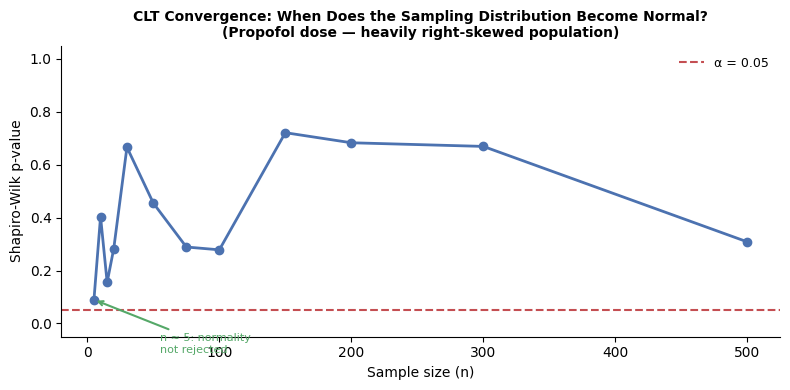

Interpretation:
- For small n (5–20), the sampling distribution is visibly skewed → CLT has not yet kicked in.
- As n increases, the distribution becomes symmetric and the Shapiro-Wilk test
  can no longer reject normality — the CLT is working.
- For this highly skewed variable, n ≈ 50–100 is needed for approximate normality.
  The "rule of 30" is a rough guide, not a guarantee.


In [9]:
# ── Convergence curve: Shapiro-Wilk p-value vs sample size ────────────────────
np.random.seed(42)

test_sizes = [5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300, 500]
sw_pvals = []

for n in test_sizes:
    means = np.array([np.random.choice(ppf_vals, size=n, replace=True).mean()
                      for _ in range(1000)])
    _, p = stats.shapiro(means[:500])
    sw_pvals.append(p)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(test_sizes, sw_pvals, 'o-', color=BLUE, linewidth=2, markersize=6)
ax.axhline(0.05, color=RED, linewidth=1.5, linestyle='--', label='α = 0.05')
ax.set_xlabel('Sample size (n)', fontsize=10)
ax.set_ylabel('Shapiro-Wilk p-value', fontsize=10)
ax.set_title('CLT Convergence: When Does the Sampling Distribution Become Normal?\n'
             '(Propofol dose — heavily right-skewed population)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.set_ylim(-0.05, 1.05)

# Annotate the threshold crossing
for i, (n, p) in enumerate(zip(test_sizes, sw_pvals)):
    if p >= 0.05:
        ax.annotate(f'n ≈ {n}: normality\nnot rejected',
                    xy=(n, p), xytext=(n + 50, p - 0.2),
                    fontsize=8, color=GREEN,
                    arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5))
        break

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- For small n (5–20), the sampling distribution is visibly skewed → CLT has not yet kicked in.")
print("- As n increases, the distribution becomes symmetric and the Shapiro-Wilk test")
print("  can no longer reject normality — the CLT is working.")
print("- For this highly skewed variable, n ≈ 50–100 is needed for approximate normality.")
print("  The \"rule of 30\" is a rough guide, not a guarantee.")

### What just happened?

Look at the four bottom panels from left to right. Something remarkable happens:

**At n = 5**, the sampling distribution is still clearly skewed — it looks a lot like the original population. Five patients is not enough to average out the skew. If you computed a mean from 5 patients and built a confidence interval assuming normality, that interval would be wrong.

**At n = 30**, the shape is starting to look more symmetric, but there is still a hint of right skew. The "rule of 30" that textbooks quote is not quite enough for this degree of skew.

**At n = 100**, the bell curve has arrived. The Shapiro–Wilk test can no longer reject normality. The red curve (the fitted normal) matches the histogram almost perfectly.

**At n = 500**, the bell curve is tight and precise. The sampling distribution is narrow because the standard error (SD / √n) is small.

**Three things to notice:**
1. The **centre** of every panel is the same — it is the true population mean. The CLT does not change what the average is; it changes the *shape* of uncertainty around it.
2. The **width** shrinks as n increases, at a rate of 1/√n. Going from n = 5 to n = 500 (100× more data) narrows the distribution by √100 = 10×.
3. The **shape** goes from skewed to normal. This is the part that matters for statistical inference — it is why t-tests and confidence intervals work on non-normal data.

> **Why this matters for your research:** You do not need your data to be normally distributed to use standard statistical methods. You just need your *sample size* to be large enough. For most clinical variables, n = 30–100 is sufficient. With VitalDB's 6,388 cases, the CLT is not even remotely a concern.

---
## What to Take Away from This Notebook

| Exercise | The Key Insight |
|---|---|
| **Probability vs. odds** | For rare outcomes like mortality, odds and probability are practically interchangeable — but for common outcomes (prevalence > 10%), odds ratios exaggerate the true relative risk. Always check the baseline rate before interpreting an OR. |
| **Distribution fitting** | Height follows a bell curve. Drug doses and lab values are log-normal (use the geometric mean, not the arithmetic mean). Transfusion counts are overdispersed — the simple Poisson model fails because most patients get zero and a few get many. |
| **Central Limit Theorem** | Even for wildly skewed data, the average becomes bell-shaped with enough observations. For heavily skewed variables, "enough" means n ≈ 50–100, not the textbook "rule of 30." With VitalDB's 6,388 cases, standard methods work just fine. |

These three ideas — knowing the difference between odds and risk, choosing the right distribution for your data, and understanding when the CLT rescues you — are the foundation for everything that follows in Part II.